# ------------ Fluid mobility prediction from logging measurment with ---------------------------------------- multiple ML models ------------------------------------------------------------------------------------------------------------------

# Import Models and Labraries

In [2]:
import math
import optuna
import chardet
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import gpboost as gpb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.interpolate import make_interp_spline
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold 
from scipy.stats import skew  
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C 
from scipy.interpolate import UnivariateSpline 

C:\Users\hp\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load the dataset

In [3]:
data1 = pd.read_excel('Mobility dataset with lithology.xlsx') # the dataset was collected from 6 well in a clay-sandstone oil reservoir
data = data1.copy()

In [4]:
data.shape

(172, 8)

In [5]:
data.head()

,depth,Neutron,Density,Resistivity,PHIE,Layer,Well,MOB
0,2786.9908,0.096524,2.496540,69.986619,0.102688,U3,BBK1,23.280960
1,2787.9269,0.108463,2.497758,38.129089,0.118129,U3,BBK1,22.463780
2,2788.5762,0.109845,2.484589,38.154890,0.088455,U3,BBK1,61.825140
3,2789.0534,0.098758,2.518072,1.051697,0.101560,U3,BBK1,2.735761
4,2790.0330,0.102687,2.509848,4.059840,0.102627,U3,BBK1,15.311000


In [6]:
data[['PHIE', 'Neutron', 'Density', 'Resistivity', 'MOB']].agg(['mean', 'std', 'min', 'max'])

,PHIE,Neutron,Density,Resistivity,MOB
mean,0.127562,0.126213,2.422739,28.650977,103.707313
std,0.027786,0.027327,0.060928,32.770853,69.256290
min,0.074546,0.078251,2.320257,0.787176,2.735119
max,0.189500,0.188718,2.576126,152.048590,229.834372


In [7]:
# calculate the missing value in the dataset
data.isnull().sum()

depth          0
Neutron        0
Density        0
Resistivity    0
PHIE           0
Layer          0
Well           0
MOB            0
dtype: int64

In [8]:
# No missing value exist so the next would not change the dataset
data = data.dropna(subset=['MOB','Resistivity','Neutron','Density','Layer'])

# Skewness reduction

In [9]:
skewness = data[['Resistivity','Neutron','Density','PHIE']].skew()

print("Skewness values:\n")
print(skewness)

Skewness values:

Resistivity    1.702992
Neutron        0.087856
Density        0.037227
PHIE           0.013377
dtype: float64


In [10]:
data['log_res'] = np.log10(data['Resistivity'] + 1e-5)

In [11]:
# verify the skewness value
skewness = data[['Neutron','Density','PHIE','log_res']].skew()

print("Skewness values:\n")
print(skewness)

Skewness values:

Neutron    0.087856
Density    0.037227
PHIE       0.013377
log_res   -0.306867
dtype: float64


In [12]:
data['log_mob'] = np.log10(data['MOB'] + 1e-5)

In [13]:
data.shape

(172, 10)

# devide the dataset into input&output and train & test 

In [14]:
X = data[['Neutron', 'Density','log_res','Layer','PHIE']]   
y = data['log_mob']  

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decode categorial variable (Layer)

In [16]:
num_cols = ['Neutron', 'Density','log_res','PHIE']
cat_cols = ["Layer"]
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat  = encoder.transform(X_test[cat_cols])


# Standardize numerical variables

In [17]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num  = scaler.transform(X_test[num_cols])
X_train = np.hstack([X_train_num, X_train_cat])
X_test  = np.hstack([X_test_num, X_test_cat])

In [18]:
# Convert to DataFrame (optional but cleaner) to see how does it look
X_train_df = pd.DataFrame(X_train)

X_train_df.head()

,0,1,2,3,4,5,6,7,8,9
0,1.567205,-1.413962,-0.647944,1.305612,0.0,0.0,0.0,0.0,1.0,0.0
1,0.180184,-0.175125,0.899681,0.227239,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.260090,0.453352,-0.571090,-0.466817,0.0,1.0,0.0,0.0,0.0,0.0
3,-1.143974,1.048528,0.987289,-1.143436,0.0,0.0,0.0,0.0,0.0,1.0
4,0.678018,-0.647609,0.802879,1.026495,0.0,0.0,1.0,0.0,0.0,0.0


# /////////////////////////////////////////////////////////////////////////

# Gaussian Process Boosting

# /////////////////////////////////////////////////////////////////////////

# 1. tunne GPBoost hyperparameters without varaince prediction

In [35]:
rkf = RepeatedKFold(n_splits=5, n_repeats=5)
likelihood = "gaussian"

def objective_gpboost(trial):
    # Hyperparameters
    learning_rate   = trial.suggest_float("learning_rate", 0.001, 10, log=True)
    min_data_in_leaf = trial.suggest_int("min_data_in_leaf", 1, 100)
    num_leaves      = trial.suggest_int("num_leaves", 2, 256)
    lambda_l2       = trial.suggest_float("lambda_l2", 0, 100)
    feature_fraction = trial.suggest_float("feature_fraction", 0.01, 1.0)
    
    r2_scores = []
    
    X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
    y_train_arr = y_train.values if hasattr(y_train, "values") else y_train
    
    for train_idx, val_idx in rkf.split(X_train_arr):
        X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
        y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]
        
        # Create datasets 
        data_train = gpb.Dataset(X_tr, label=y_tr)
        
        # GPBoost parameters
        params = {
            'objective': 'regression',
            'verbose': -1,
            'learning_rate': learning_rate,
            'min_data_in_leaf': int(min_data_in_leaf),
            'num_leaves': int(num_leaves),
            'lambda_l2': lambda_l2,
            'feature_fraction': feature_fraction,
            'max_depth': -1
        }
        
        # Train model
        gp_model = gpb.GPModel(likelihood=likelihood, num_data=len(X_tr))
        model = gpb.train(
                params=params,
                train_set=data_train,
                num_boost_round=100,
                verbose_eval=-1
            )
            
            # Predictions
        y_val_pred = model.predict(X_val)
        r2_scores.append(r2_score(y_val, y_val_pred))
    
    return np.mean(r2_scores)
 

# GPBOOST OPTIMIZATION

print("\n" + "=" * 80)
print("GPBOOST HYPERPARAMETER TUNING (GPBoost Library)")
print("=" * 80)
 
sampler_gpb = optuna.samplers.TPESampler(seed=38, multivariate=True, n_startup_trials=20)
pruner_gpb = optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=5)
 
study_gpb = optuna.create_study(
    direction="maximize",
    sampler=sampler_gpb,
    pruner=pruner_gpb
)
 
print("\nRunning Optuna optimization for GPBoost...")
study_gpb.optimize(objective_gpboost, n_trials=800, show_progress_bar=False) 
 
best_params_gpb = study_gpb.best_params
best_value_gpb = study_gpb.best_value
 
print("\n Best GPBoost hyperparameters:")
print(best_params_gpb)
print(f"\n🎯 Best Repeated CV R² (GPBoost): {best_value_gpb:.4f}")


C:\Users\hp\anaconda3\Lib\site-packages\optuna\samplers\_tpe\sampler.py:319: ExperimentalWarning: ``multivariate`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-05-31 18:16:06,948] A new study created in memory with name: no-name-5bceb350-08aa-49f7-85a8-51471919bd56



GPBOOST HYPERPARAMETER TUNING (GPBoost Library)

Running Optuna optimization for GPBoost...


[I 2026-05-31 18:16:07,729] Trial 0 finished with value: -0.06329592195387745 and parameters: {'learning_rate': 0.03460130495227987, 'min_data_in_leaf': 86, 'num_leaves': 242, 'lambda_l2': 70.28248936107295, 'feature_fraction': 0.6372977561996928}. Best is trial 0 with value: -0.06329592195387745.
[I 2026-05-31 18:16:08,338] Trial 1 finished with value: 0.613439409022241 and parameters: {'learning_rate': 0.2653659082354948, 'min_data_in_leaf': 21, 'num_leaves': 100, 'lambda_l2': 25.89831637514316, 'feature_fraction': 0.08386120860557023}. Best is trial 1 with value: 0.613439409022241.
[I 2026-05-31 18:16:08,782] Trial 2 finished with value: 0.3564911172287985 and parameters: {'learning_rate': 0.013299272927965506, 'min_data_in_leaf': 44, 'num_leaves': 125, 'lambda_l2': 86.84894862873948, 'feature_fraction': 0.5343330901642418}. Best is trial 1 with value: 0.613439409022241.
[I 2026-05-31 18:16:09,198] Trial 3 finished with value: 0.6194145316880679 and parameters: {'learning_rate': 0.1


 Best GPBoost hyperparameters:
{'learning_rate': 0.08544023126025235, 'min_data_in_leaf': 2, 'num_leaves': 215, 'lambda_l2': 4.759835217950617, 'feature_fraction': 0.9328686259070161}

🎯 Best Repeated CV R² (GPBoost): 0.9549


# Train final GPBoost model

In [36]:
print("\n" + "=" * 30)
print("TRAINING FINAL GPBOOST MODEL")
print("=" * 30)
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train
X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

# Train final GP Boosting model
F_train_final = np.full(len(y_train_arr), y_train_arr.mean())
F_test_final = np.full(len(y_test_arr), y_train_arr.mean())


params_final = {
    'objective': 'regression',
    'verbose': -1,
    'learning_rate': best_params_gpb['learning_rate'],
    'min_data_in_leaf': int(best_params_gpb['min_data_in_leaf']),
    'num_leaves': int(best_params_gpb['num_leaves']),
    'lambda_l2': best_params_gpb['lambda_l2'],
    'feature_fraction': best_params_gpb['feature_fraction'],
    'max_depth': -1
}

data_train = gpb.Dataset(X_train_arr, label=y_train_arr)
gp_model_final = gpb.GPModel(likelihood=likelihood, num_data=len(X_train_arr))

gpb_model = gpb.train(
    params=params_final,
    train_set=data_train,
    num_boost_round=100,
    verbose_eval=-1
)

print("GPBoost model training complete")



TRAINING FINAL GPBOOST MODEL
GPBoost model training complete


# Evaluation of the final model

In [37]:
# =========================
# EVALUATION & COMPARISON
# =========================
print("\n" + "=" * 30)
print("MODEL EVALUATION & COMPARISON")
print("=" * 30)

gpb_train_pred_log = gpb_model.predict(X_train_arr)
gpb_test_pred_log = gpb_model.predict(X_test_arr)

r2_gpb_train_log = r2_score(y_train_arr, gpb_train_pred_log)
r2_gpb_test_log = r2_score(y_test_arr, gpb_test_pred_log)
rmse_gpb_log = np.sqrt(mean_squared_error(y_test_arr, gpb_test_pred_log))
print("\n LOG SPACE EVALUATION (standardized)")
print("-" * 64)
print(f"{'Model':<20} {'Train R²':<15} {'Test R²':<15} {'Test RMSE':<15}")
print("-" * 64)

print(f"{'GPBoost':<20} {r2_gpb_train_log:<15.4f} {r2_gpb_test_log:<15.4f} {rmse_gpb_log:<15.4f}")

y_train_physical = 10**y_train_arr
y_test_physical = 10**y_test_arr

gpb_train_physical = 10**gpb_train_pred_log
gpb_test_physical = 10**gpb_test_pred_log


r2_gpb_train_phys = r2_score(y_train_physical, gpb_train_physical)
r2_gpb_test_phys = r2_score(y_test_physical, gpb_test_physical)


rmse_gpb = np.sqrt(mean_squared_error(y_test_physical, gpb_test_physical))
mae_gpb = mean_absolute_error(y_test_physical, gpb_test_physical)

print("\n PHYSICAL SPACE EVALUATION (10^y)")
print("-" * 73)
print(f"{'Model':<20} {'Train R²':<15} {'Test R²':<15} {'RMSE':<15} {'MAE':<15}")
print("-" * 73)
print(f"{'GPBoost':<20} {r2_gpb_train_phys:<15.4f} {r2_gpb_test_phys:<15.4f} {rmse_gpb:<15.4f} {mae_gpb:<15.4f}")



MODEL EVALUATION & COMPARISON

 LOG SPACE EVALUATION (standardized)
----------------------------------------------------------------
Model                Train R²        Test R²         Test RMSE      
----------------------------------------------------------------
GPBoost              0.9981          0.9764          0.0484         

 PHYSICAL SPACE EVALUATION (10^y)
-------------------------------------------------------------------------
Model                Train R²        Test R²         RMSE            MAE            
-------------------------------------------------------------------------
GPBoost              0.9991          0.9737          10.6947         8.2260         


# Plot the final results of evaluation

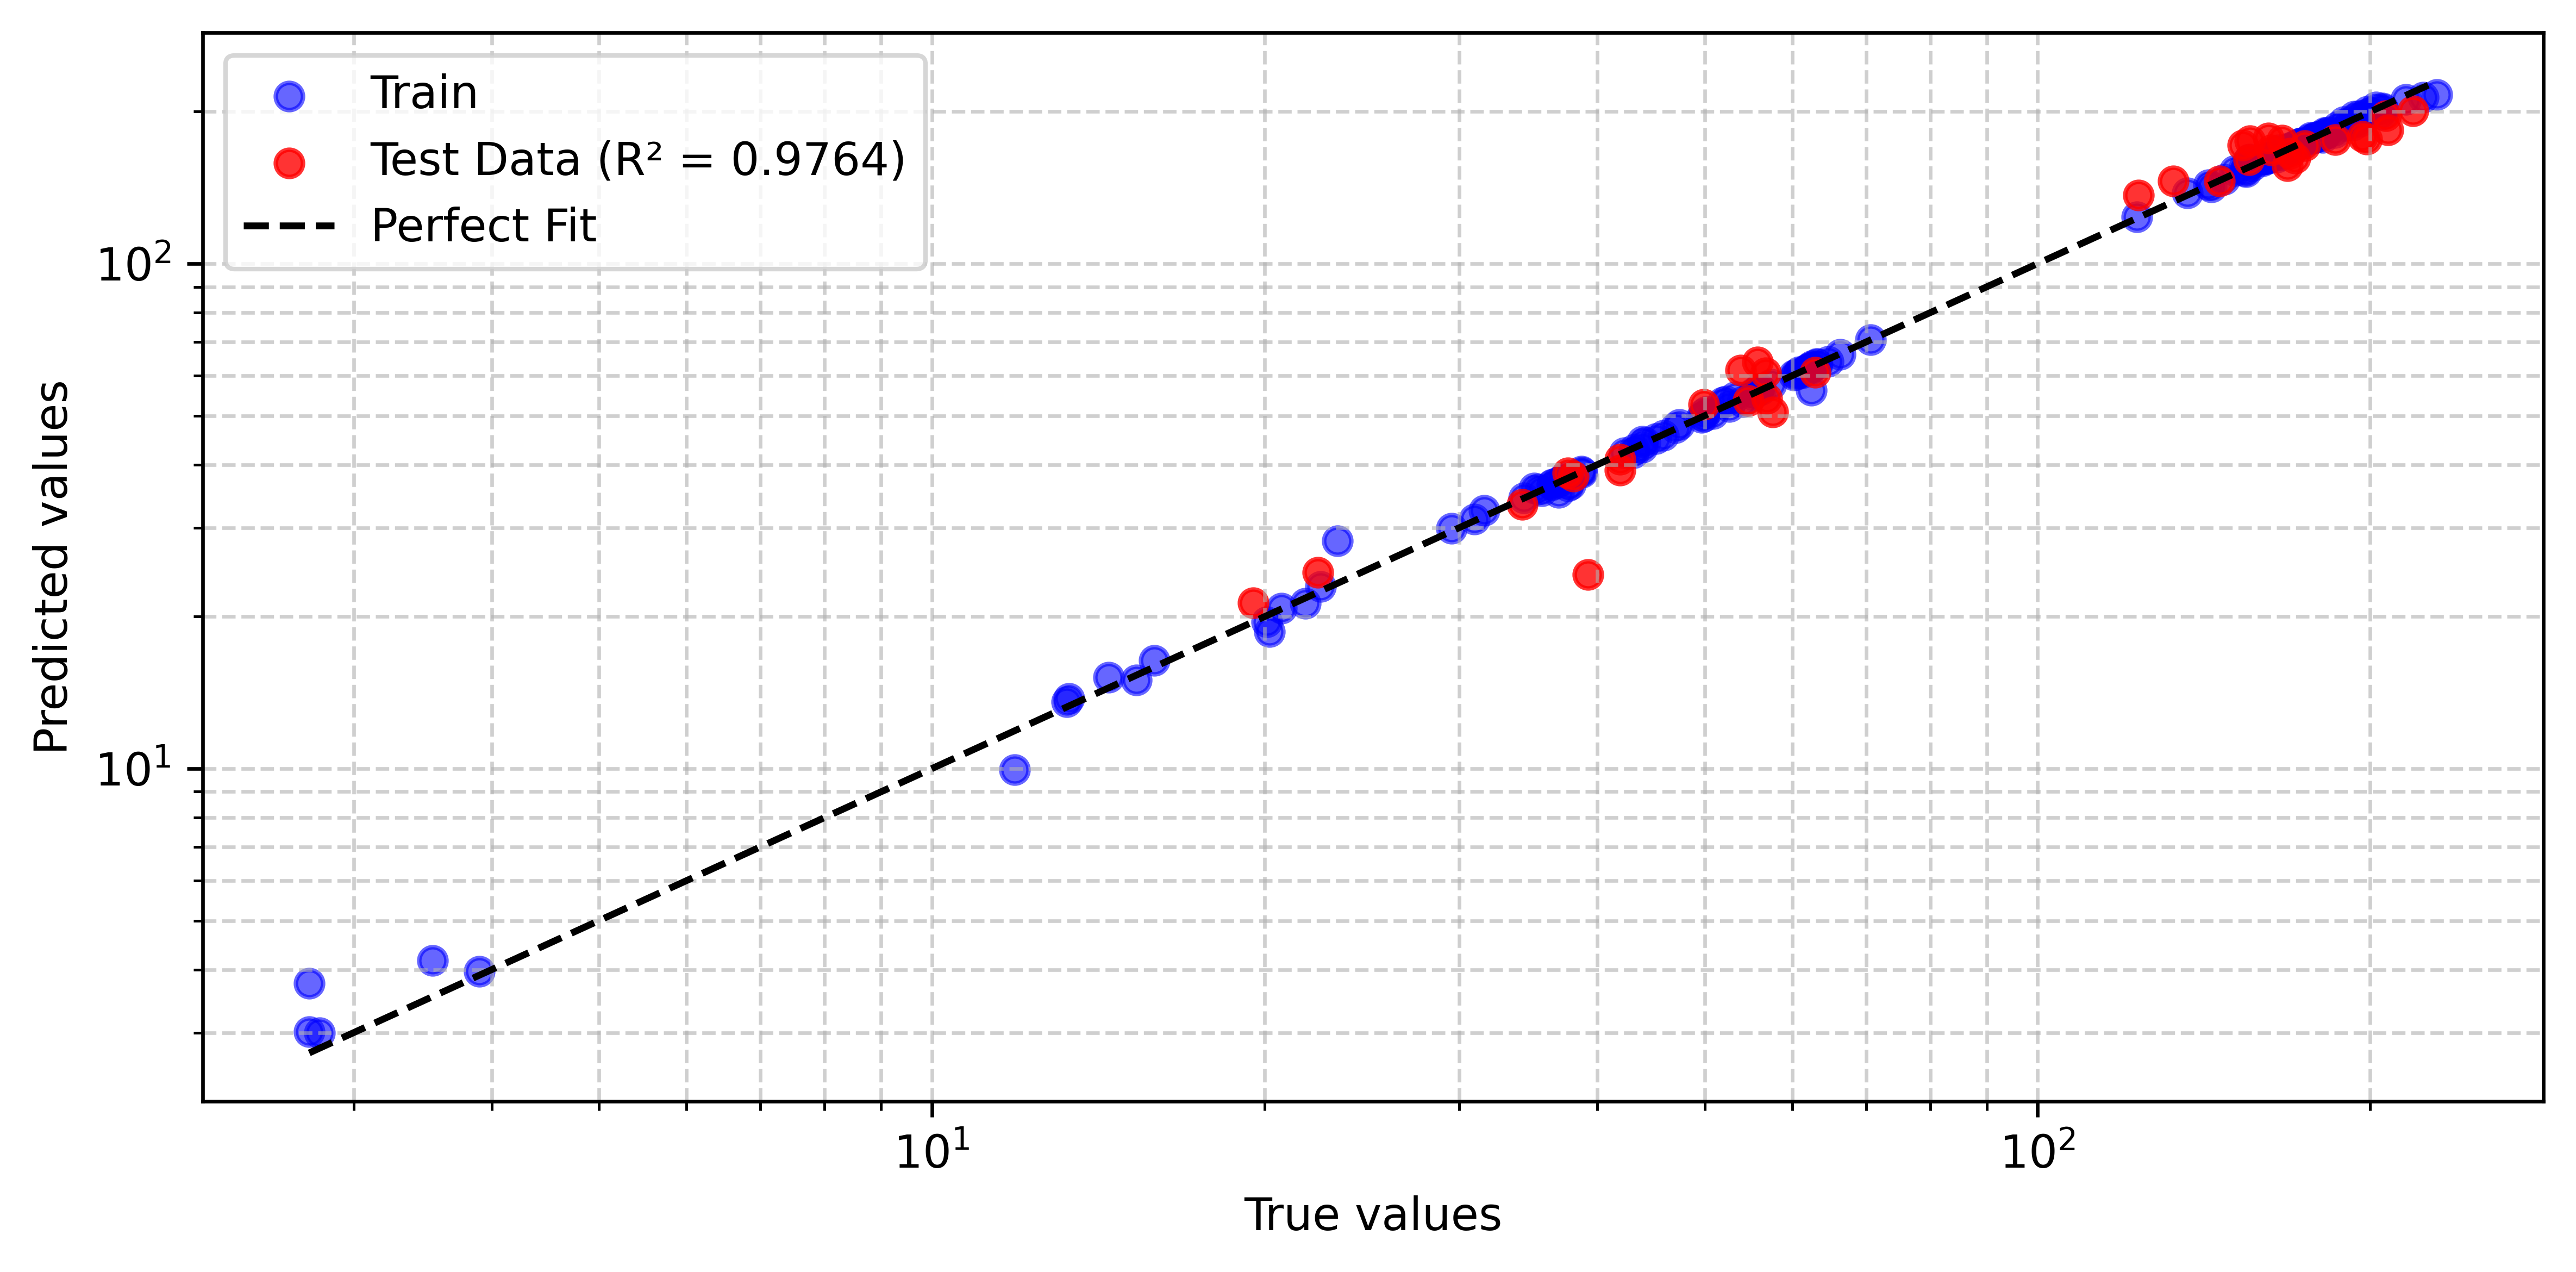

In [38]:
plt.figure(figsize=(8, 4),dpi=600)
plt.scatter(y_train_physical, gpb_train_physical, color='blue', alpha=0.6, label='Train')
plt.scatter(y_test_physical, gpb_test_physical, color='red', alpha=0.8, label=f'Test Data (R² = {r2_gpb_test_log:.4f})'
)
plt.xscale("log")
plt.yscale("log")
y_min_phys = min(y_train_physical.min(), y_test_physical.min())
y_max_phys = max(y_train_physical.max(), y_test_physical.max())
plt.plot([y_min_phys, y_max_phys], [y_min_phys, y_max_phys], 'k--', lw=1.5, label='Perfect Fit')

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# distrubition of relative error & AARE

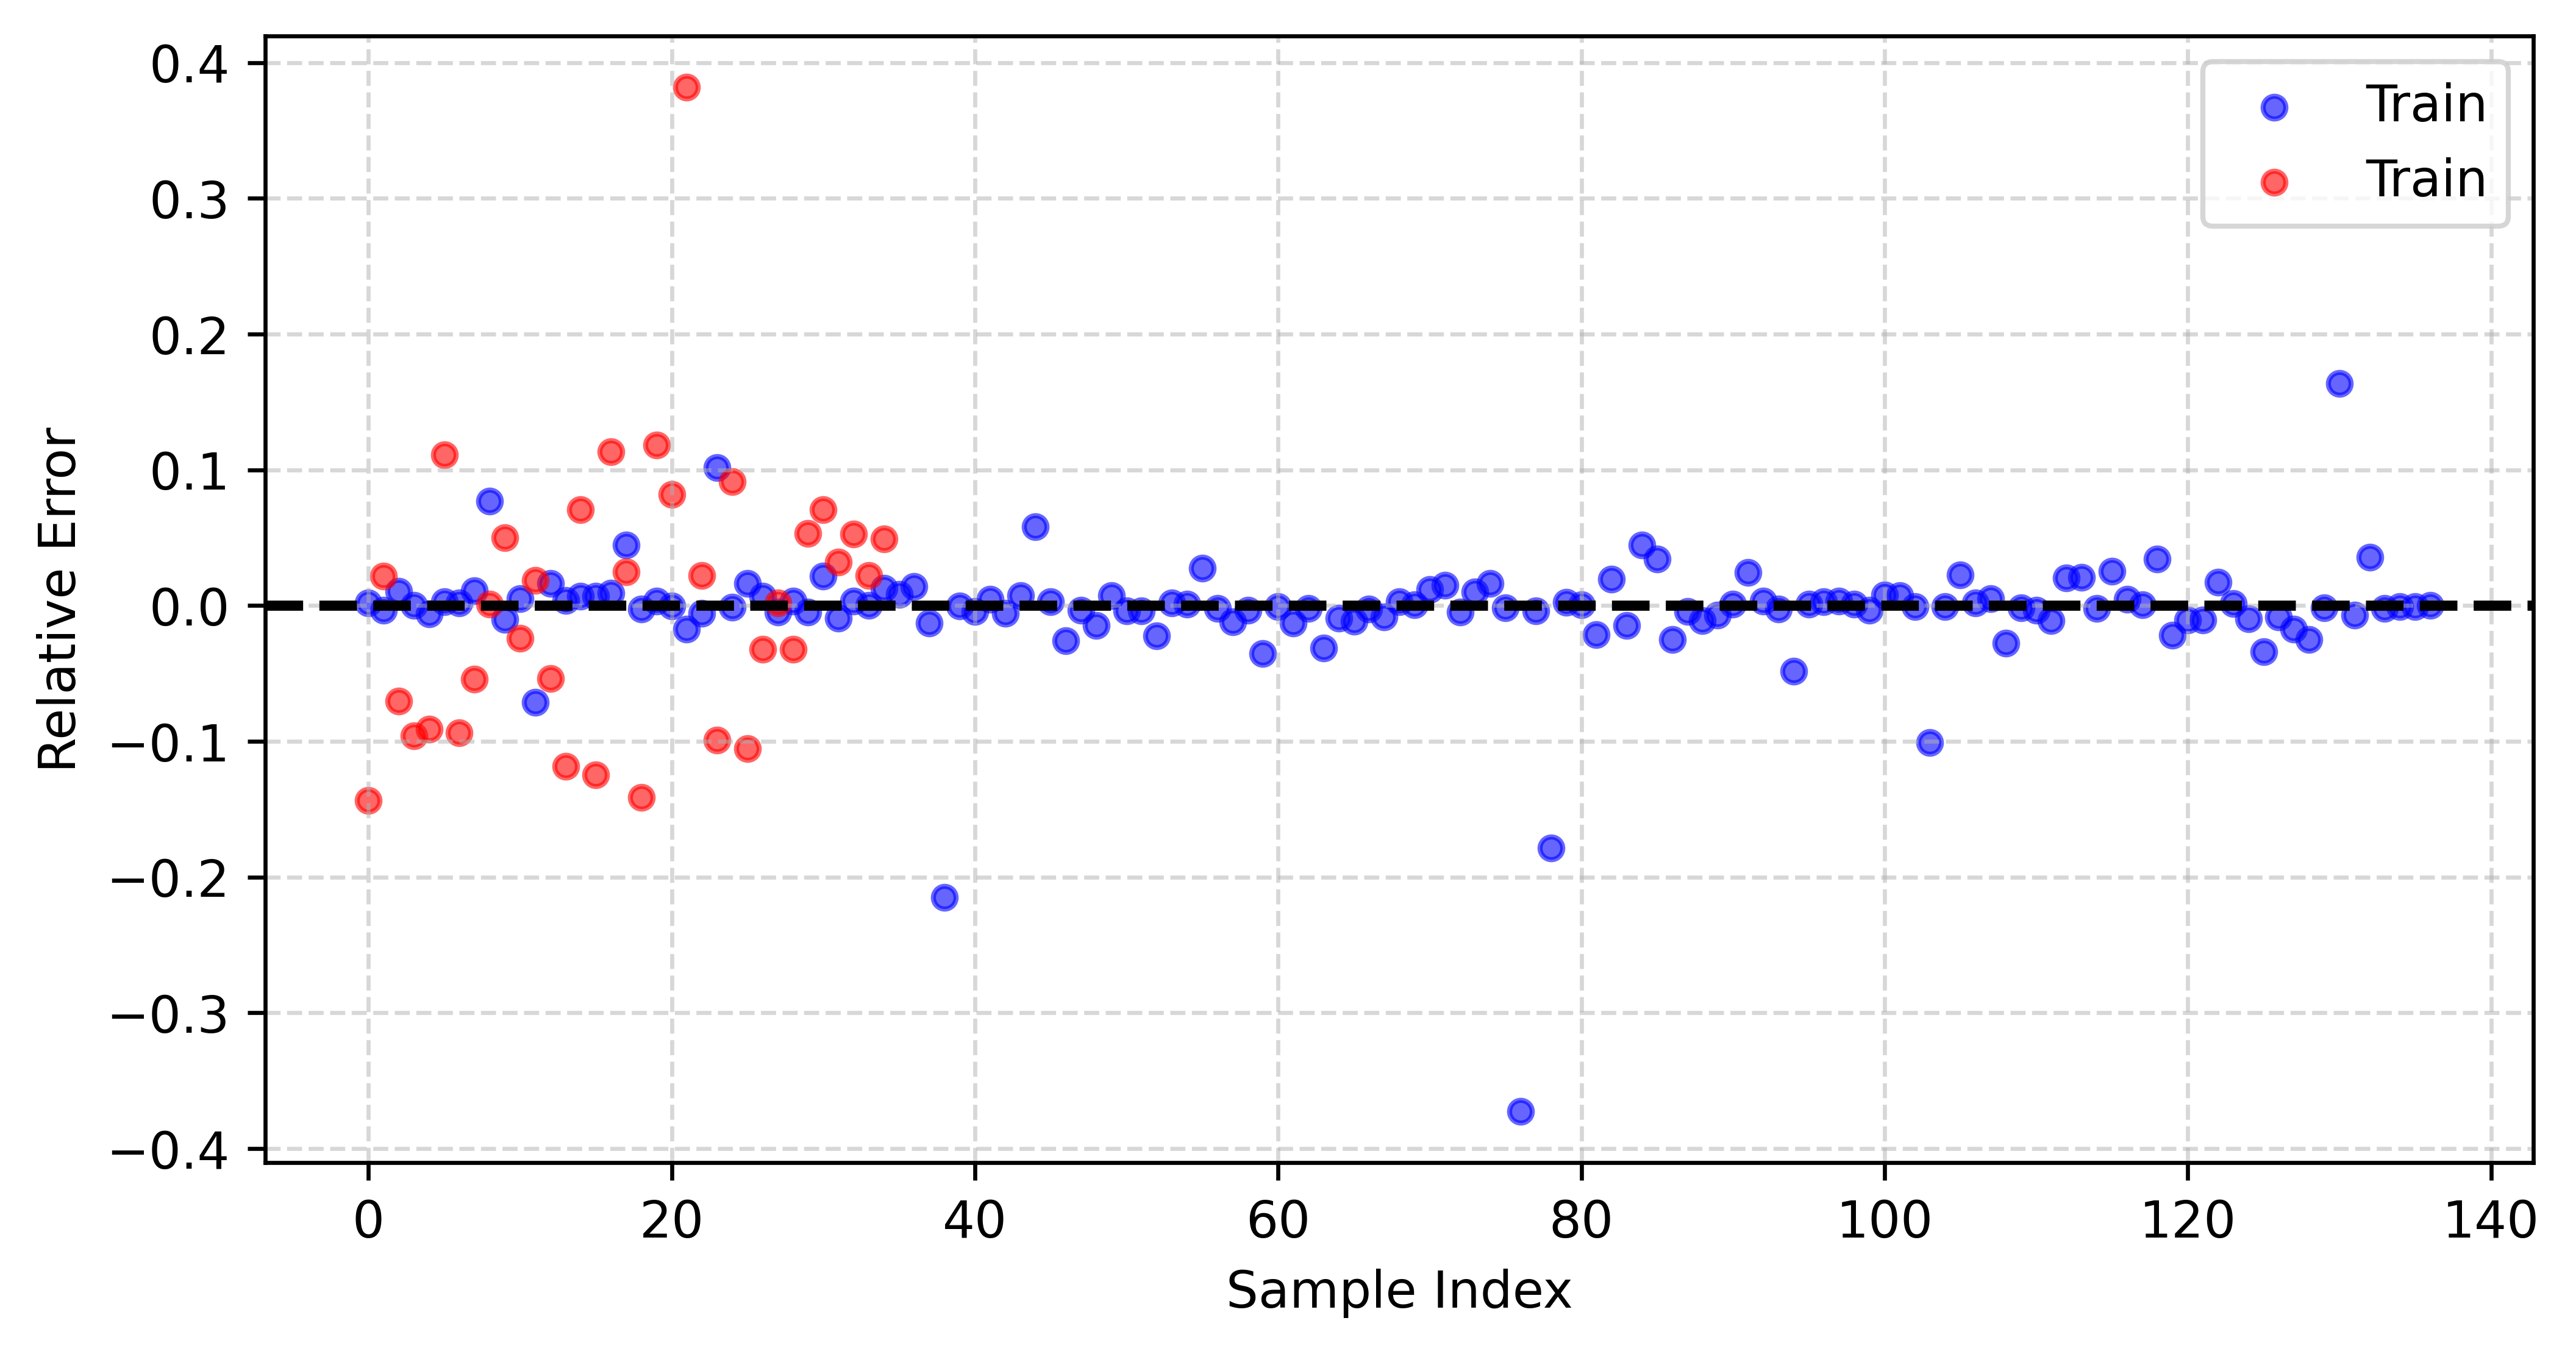

In [47]:
error_train =(y_train_physical - gpb_train_physical)/y_train_physical
error_test  = (y_test_physical  - gpb_test_physical)/y_test_physical


plt.figure(figsize=(8,4),dpi=600)

plt.scatter(range(len(error_train)), error_train, color='blue', alpha=0.6, label='Train', s=20)

plt.scatter(range(len(error_test)), error_test, color='red', alpha=0.6, label='Train', s=20)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.xlabel("Sample Index")
plt.ylabel("Relative Error")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [48]:
abs_error_train = np.mean(np.abs(error_train))
abs_error_test = np.mean(np.abs(error_test))
print(abs_error_train)
print(abs_error_test)

0.01929480795065322
0.07623319516530078


# 2. GPBoost with covariance and mean prediction

In [49]:
group_data = data["Layer"]                       
feature_cols = ["depth", "Neutron", "Density", "log_res", "PHIE"]
X1 = data[feature_cols]
y1 = data["log_mob"]
groups = data["Layer"]   

X_train1, X_test1, y_train1, y_test1, groups_train, groups_test = train_test_split(
    X1, y1, group_data,
    test_size=0.2,
    random_state=42
)

In [50]:
scaler = StandardScaler()

X_train1 = scaler.fit_transform(X_train1)
X_test1  = scaler.transform(X_test1)

In [51]:
rkf = RepeatedKFold(n_splits=5, n_repeats=5)
likelihood = "gaussian"


def objective_gpboost(trial):

    learning_rate    = trial.suggest_float("learning_rate", 0.01, 10, log=True)
    min_data_in_leaf = trial.suggest_int("min_data_in_leaf", 1, 100)
    num_leaves       = trial.suggest_int("num_leaves", 2, 256)
    lambda_l2        = trial.suggest_float("lambda_l2", 0, 100)
    feature_fraction = trial.suggest_float("feature_fraction", 0.5, 1.0)
    lr    = trial.suggest_float("lr", 0.01, 10, log=True)
    
    X_train_arr      = X_train1.values if hasattr(X_train1, "values") else X_train1
    y_train_arr      = y_train1.values if hasattr(y_train1, "values") else y_train1
    groups_train_arr = groups_train.values if hasattr(groups_train, "values") else groups_train

    r2_scores = []
    for train_idx, val_idx in rkf.split(X_train_arr):
        X_tr,  X_val  = X_train_arr[train_idx],       X_train_arr[val_idx]
        y_tr,  y_val  = y_train_arr[train_idx],       y_train_arr[val_idx]
        g_tr,  g_val  = groups_train_arr[train_idx],  groups_train_arr[val_idx]

        data_train = gpb.Dataset(X_tr, label=y_tr)

        params = {
            'objective':        'regression',
            'verbose':          -1,
            'learning_rate':    learning_rate,
            'min_data_in_leaf': int(min_data_in_leaf),
            'num_leaves':       int(num_leaves),
            'lambda_l2':        lambda_l2,
            'feature_fraction': feature_fraction,
            'max_depth':         -1  # depth is indirectly controlled by num_leaves instead
        }

        # GPBoost handles categorical natively
        gp_model = gpb.GPModel(
            group_data=g_tr,
            likelihood=likelihood
        )

        gp_model.set_optim_params(params={
            "optimizer_cov": "gradient_descent",
            "lr_cov": lr
        })

        model = gpb.train(
            params=params,
            train_set=data_train,
            gp_model=gp_model,
            num_boost_round=100,
            verbose_eval=-1
        )
        pred_result = model.predict(
             data=X_val,
             group_data_pred=g_val,
             predict_var=True,
             pred_latent=False )

        y_val_pred_mean = pred_result["response_mean"]  
        y_val_pred_var  = pred_result["response_var"] 

        r2 = r2_score(y_val, y_val_pred_mean)
        r2_scores.append(r2)
    
    return np.mean(r2_scores)

# =========================
#  GPBOOST OPTIMIZATION
# =========================
print("\n" + "=" * 80)
print("GPBOOST HYPERPARAMETER TUNING (GPBoost Library)")
print("=" * 80)

sampler_gpb = optuna.samplers.TPESampler(seed=38, multivariate=True, n_startup_trials=20)
pruner_gpb  = optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=3)

study_gpb = optuna.create_study(
    direction="maximize",
    sampler=sampler_gpb,
    pruner=pruner_gpb
)

print("\nRunning Optuna optimization for GPBoost (mean + covariance prediction)...")
study_gpb.optimize(objective_gpboost, n_trials=800, show_progress_bar=False)

best_params_gpb = study_gpb.best_params
best_value_gpb  = study_gpb.best_value

print("\n Best GPBoost hyperparameters:")
print(best_params_gpb)
print(f"\n🎯 Best Repeated CV R² (GPBoost): {best_value_gpb:.4f}")

C:\Users\hp\anaconda3\Lib\site-packages\optuna\samplers\_tpe\sampler.py:319: ExperimentalWarning: ``multivariate`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-05-31 18:57:32,737] A new study created in memory with name: no-name-9195e43c-2dfd-4b1d-8ae2-035d651ac0b1



GPBOOST HYPERPARAMETER TUNING (GPBoost Library)

Running Optuna optimization for GPBoost (mean + covariance prediction)...


[I 2026-05-31 18:57:34,029] Trial 0 finished with value: 0.6741605254406295 and parameters: {'learning_rate': 0.14266563000201307, 'min_data_in_leaf': 86, 'num_leaves': 242, 'lambda_l2': 70.28248936107295, 'feature_fraction': 0.8168170485857034, 'lr': 0.6574819673047754}. Best is trial 0 with value: 0.6741605254406295.
[I 2026-05-31 18:57:34,753] Trial 1 finished with value: 0.6429773658998963 and parameters: {'learning_rate': 0.03984561446945944, 'min_data_in_leaf': 39, 'num_leaves': 68, 'lambda_l2': 7.460728141976791, 'feature_fraction': 0.6404784873388953, 'lr': 0.2066819038705736}. Best is trial 0 with value: 0.6741605254406295.
[I 2026-05-31 18:57:35,747] Trial 2 finished with value: 0.6627209987962192 and parameters: {'learning_rate': 0.2816742397213298, 'min_data_in_leaf': 87, 'num_leaves': 137, 'lambda_l2': 56.226314423475586, 'feature_fraction': 0.7355276719975954, 'lr': 1.1655368825224182}. Best is trial 0 with value: 0.6741605254406295.
[I 2026-05-31 18:57:37,108] Trial 3 fi


 Best GPBoost hyperparameters:
{'learning_rate': 0.010692495339646224, 'min_data_in_leaf': 1, 'num_leaves': 2, 'lambda_l2': 84.24945858819612, 'feature_fraction': 0.9439208025469937, 'lr': 0.22817182221163573}

🎯 Best Repeated CV R² (GPBoost): 0.9614


In [52]:
# =========================
# TRAINING FINAL GPBOOST MODEL
# =========================
print("\n" + "=" * 80)
print("TRAINING FINAL GPBOOST MODEL")
print("=" * 80)

X_train_arr      = X_train1.values if hasattr(X_train1, "values") else X_train1
y_train_arr      = y_train1.values if hasattr(y_train1, "values") else y_train1
X_test_arr       = X_test1.values  if hasattr(X_test1,  "values") else X_test1
y_test_arr       = y_test1.values  if hasattr(y_test1,  "values") else y_test1
groups_train_arr = groups_train.values if hasattr(groups_train, "values") else groups_train
groups_test_arr  = groups_test.values  if hasattr(groups_test,  "values") else groups_test

params_final = {
    'objective':        'regression',
    'verbose':          -1,
    'learning_rate':    best_params_gpb['learning_rate'],
    'min_data_in_leaf': int(best_params_gpb['min_data_in_leaf']),
    'num_leaves':       int(best_params_gpb['num_leaves']),
    'lambda_l2':        best_params_gpb['lambda_l2'],
    'feature_fraction': best_params_gpb['feature_fraction'],
    'max_depth':        -1
}

data_train_final = gpb.Dataset(X_train_arr, label=y_train_arr)

gp_model_final = gpb.GPModel(
    group_data=groups_train_arr,      # group IDs for training
    likelihood=likelihood
)

gp_model_final.set_optim_params(params={
    "optimizer_cov": "gradient_descent",
     "lr_cov":  1.8482714739848778
})

gpb_model = gpb.train(
    params=params_final,
    train_set=data_train_final,
    gp_model=gp_model_final,          
    num_boost_round=100,
    verbose_eval=-1
)

print("✅ GPBoost model training complete")


# =========================
# EVALUATION & COMPARISON
# =========================
print("\n" + "=" * 80)
print("MODEL EVALUATION & COMPARISON")
print("=" * 80)

# ── Predictions (log scale) ───────────────────────────────────────────────────
train_pred = gpb_model.predict(
    data=X_train_arr,
    group_data_pred=groups_train_arr,
    predict_var=True,
    pred_latent=False
)
test_pred = gpb_model.predict(
    data=X_test_arr,
    group_data_pred=groups_test_arr,
    predict_var=True,
    pred_latent=False
)

gpb_train_pred_log = train_pred["response_mean"]
gpb_test_pred_log  = test_pred["response_mean"]
gpb_test_pred_var  = test_pred["response_var"]     # predictive variance (log scale)

# ── Log scale metrics ─────────────────────────────────────────────────────────
r2_gpb_train_log = r2_score(y_train_arr, gpb_train_pred_log)
r2_gpb_test_log  = r2_score(y_test_arr,  gpb_test_pred_log)
rmse_gpb_log          = np.sqrt(mean_squared_error(y_test_arr,  gpb_test_pred_log))
print("\n📊 LOG SPACE EVALUATION (standardized)")
print("-" * 80)
print(f"{'Model':<20} {'Train R²':<15} {'Test R²':<15} {'Test RMSE':<15}")
print("-" * 80)
print(f"{'GPBoost':<20} {r2_gpb_train_log:<15.4f} {r2_gpb_test_log:<15.4f} {rmse_gpb_log:<15.4f}")

# ── Physical scale metrics ────────────────────────────────────────────────────
y_train_physical   = 10 ** y_train_arr
y_test_physical    = 10 ** y_test_arr
gpb_train_physical = 10 ** gpb_train_pred_log
gpb_test_physical  = 10 ** gpb_test_pred_log

r2_gpb_train_phys  = r2_score(y_train_physical, gpb_train_physical)
r2_gpb_test_phys   = r2_score(y_test_physical,  gpb_test_physical)
rmse_gpb           = np.sqrt(mean_squared_error(y_test_physical, gpb_test_physical))
mae_gpb            = mean_absolute_error(y_test_physical, gpb_test_physical)

print("\n📊 PHYSICAL SPACE EVALUATION (10^y)")
print("-" * 80)
print(f"{'Model':<20} {'Train R²':<15} {'Test R²':<15} {'RMSE':<15} {'MAE':<15}")
print("-" * 80)
print(f"{'GPBoost':<20} {r2_gpb_train_phys:<15.4f} {r2_gpb_test_phys:<15.4f} {rmse_gpb:<15.4f} {mae_gpb:<15.4f}")



TRAINING FINAL GPBOOST MODEL
✅ GPBoost model training complete

MODEL EVALUATION & COMPARISON

📊 LOG SPACE EVALUATION (standardized)
--------------------------------------------------------------------------------
Model                Train R²        Test R²         Test RMSE      
--------------------------------------------------------------------------------
GPBoost              0.9880          0.9716          0.0531         

📊 PHYSICAL SPACE EVALUATION (10^y)
--------------------------------------------------------------------------------
Model                Train R²        Test R²         RMSE            MAE            
--------------------------------------------------------------------------------
GPBoost              0.9849          0.9604          13.1330         9.4823         


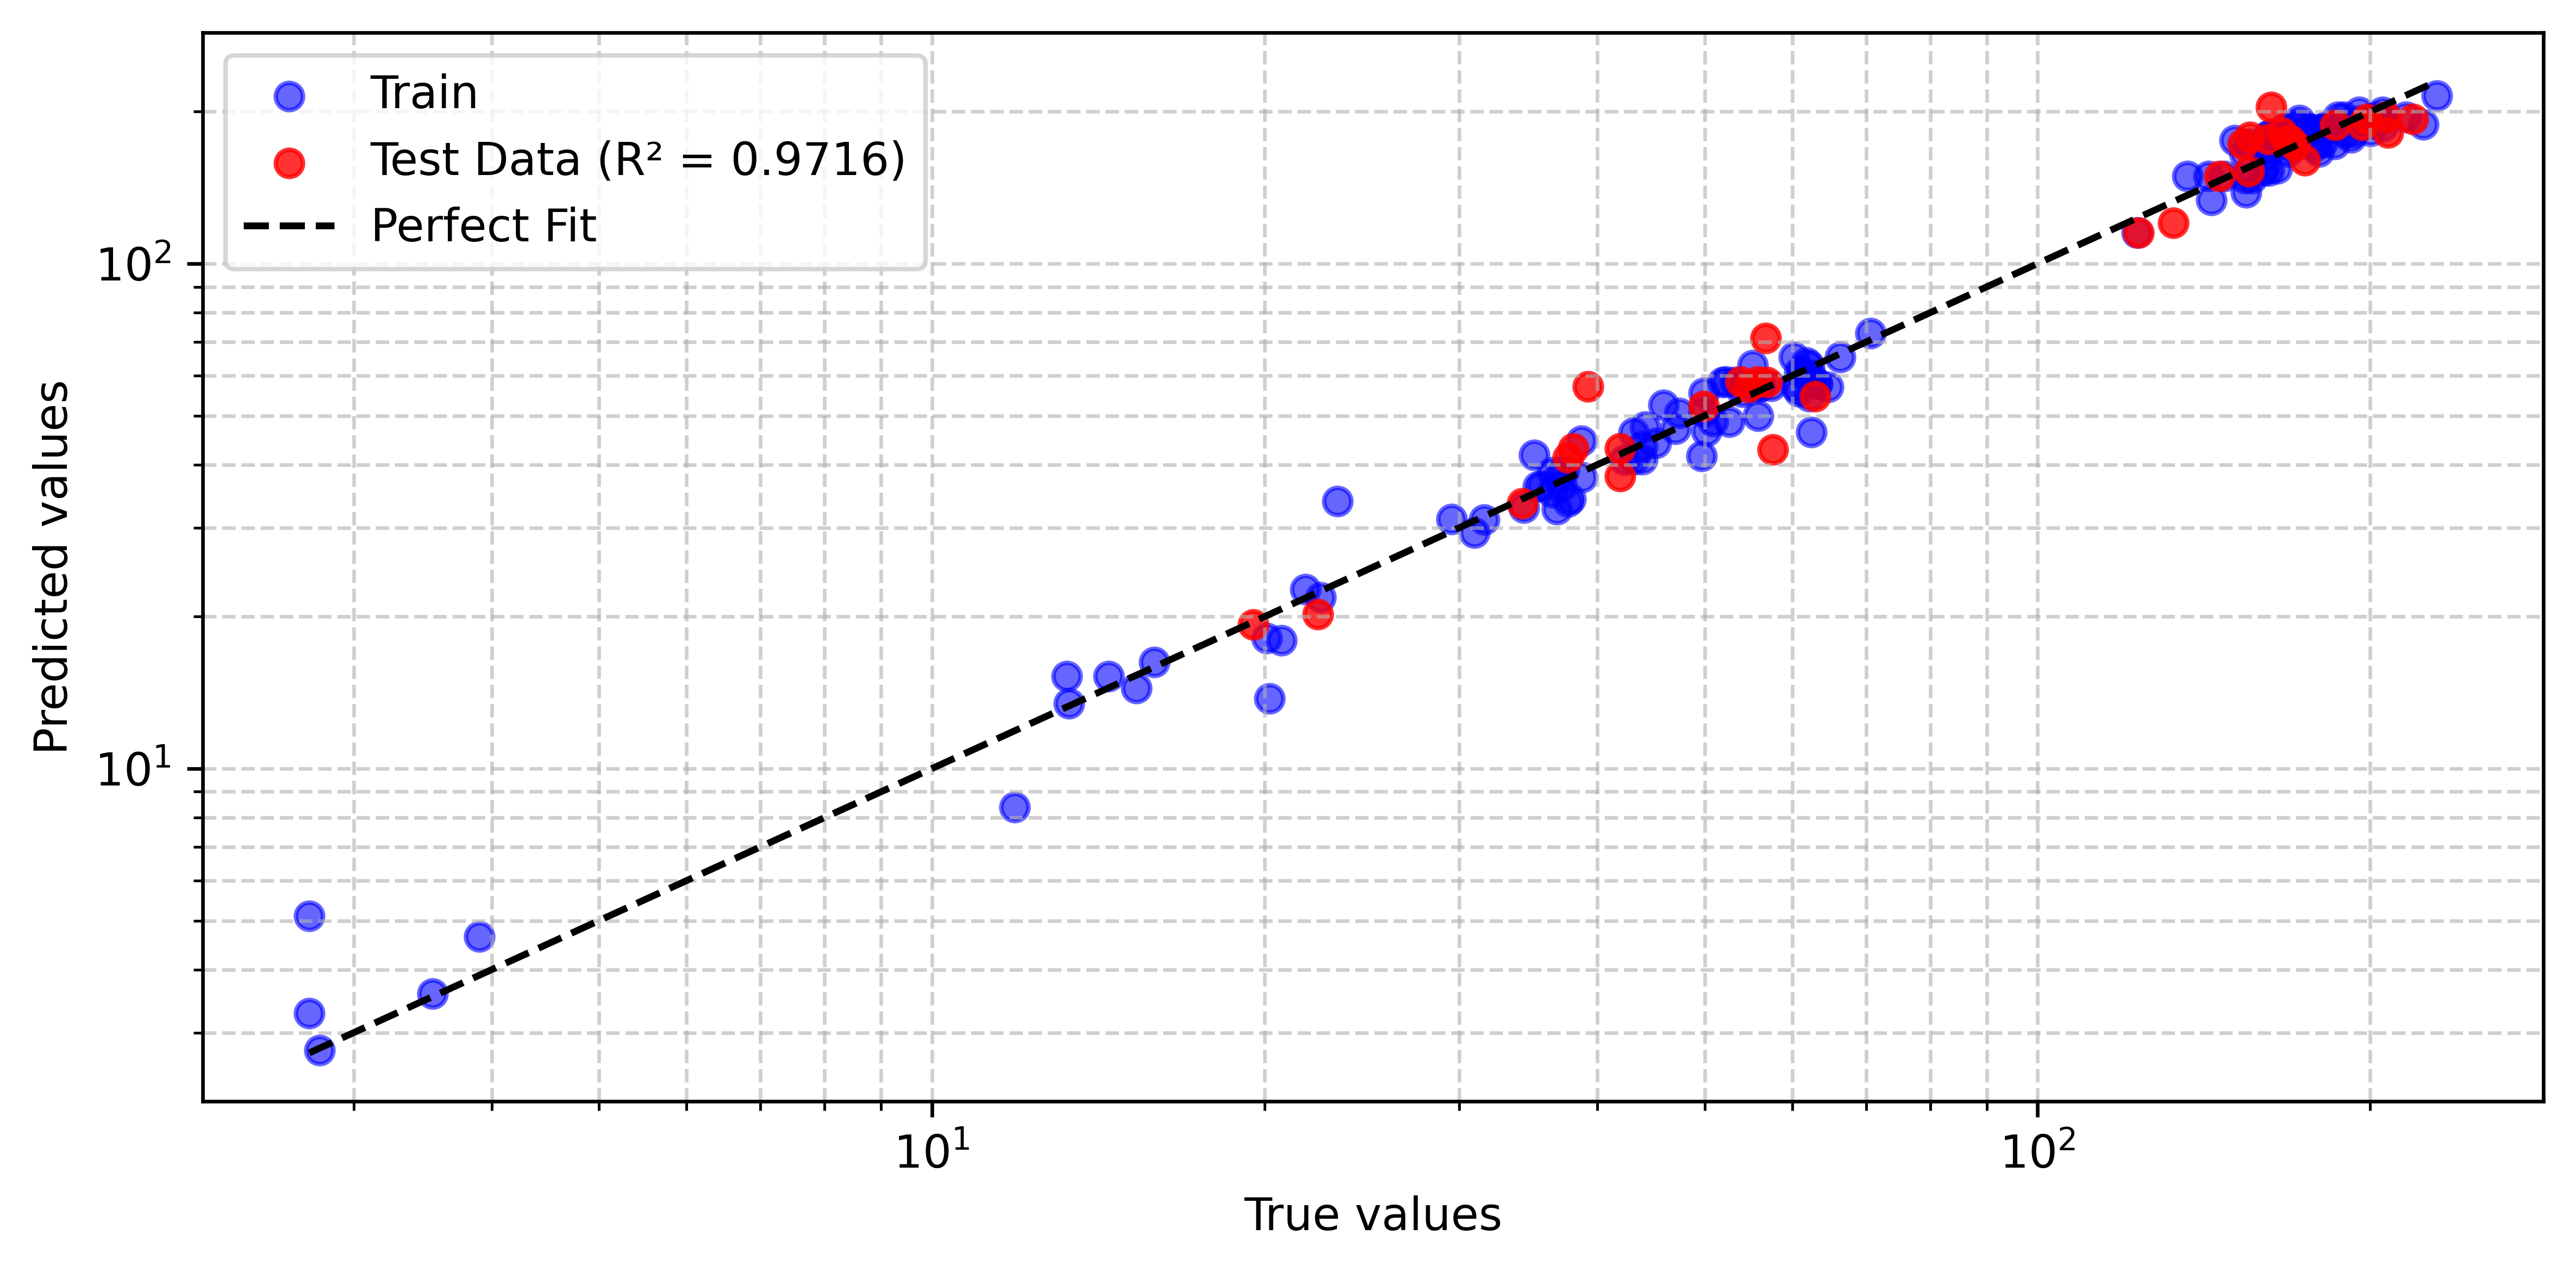

In [54]:
# ── Scatter plot: physical scale ──────────────────────────────────────────────
plt.figure(figsize=(8, 4),dpi=600)
plt.scatter(y_train_physical, gpb_train_physical, color='blue', alpha=0.6, label='Train')
plt.scatter(y_test_physical,  gpb_test_physical,  color='red',  alpha=0.8, label=f'Test Data (R² = {r2_gpb_test_log:.4f})')
plt.xscale("log")
plt.yscale("log")

y_min_phys = min(y_train_physical.min(), y_test_physical.min())
y_max_phys = max(y_train_physical.max(), y_test_physical.max())
plt.plot([y_min_phys, y_max_phys], [y_min_phys, y_max_phys], 'k--', lw=1.5, label='Perfect Fit')
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Interval-Aware Evaluation of GPBoost Predictions 

In [59]:
# ==========================================================
# 95% CONFIDENCE INTERVAL (LOG SCALE)
# ==========================================================
gpb_test_std_log = np.sqrt(gpb_test_pred_var)

ci_lower_log = gpb_test_pred_log - 1.96 * gpb_test_std_log
ci_upper_log = gpb_test_pred_log + 1.96 * gpb_test_std_log

# Log-scale actuals
y_actual_log     = y_test_arr                  # already in log scale
gpb_pred_log     = gpb_test_pred_log           # predictions in log scale

# Physical scale
y_actual_phys    = 10 ** y_actual_log
y_pred_phys      = 10 ** gpb_pred_log
ci_lower_phys    = 10 ** ci_lower_log
ci_upper_phys    = np.maximum(10 ** ci_upper_log, 1e-10)

# ==========================================================
# OUTSIDE / INSIDE MASKS
# ==========================================================
outside_mask_log = (y_actual_log < ci_lower_log) | (y_actual_log > ci_upper_log)
inside_mask_log  = ~outside_mask_log

outside_mask_phys = (y_actual_phys < ci_lower_phys) | (y_actual_phys > ci_upper_phys)
inside_mask_phys  = ~outside_mask_phys

n_total   = len(y_actual_log)
n_outside = outside_mask_log.sum()
n_inside  = inside_mask_log.sum()

# ==========================================================
# INTERVAL-ADJUSTED PREDICTIONS
# ==========================================================
# --- Log scale ---
y_pred_adjusted_log = gpb_pred_log.copy()
y_pred_adjusted_log[y_actual_log > ci_upper_log] = ci_upper_log[y_actual_log > ci_upper_log]
y_pred_adjusted_log[y_actual_log < ci_lower_log] = ci_lower_log[y_actual_log < ci_lower_log]
y_pred_adjusted_log[inside_mask_log]             = y_actual_log[inside_mask_log]

# --- Physical scale ---
y_pred_adjusted_phys = y_pred_phys.copy()
y_pred_adjusted_phys[y_actual_phys > ci_upper_phys] = ci_upper_phys[y_actual_phys > ci_upper_phys]
y_pred_adjusted_phys[y_actual_phys < ci_lower_phys] = ci_lower_phys[y_actual_phys < ci_lower_phys]
y_pred_adjusted_phys[inside_mask_phys]              = y_actual_phys[inside_mask_phys]

# ==========================================================
# METRICS
# ==========================================================
# Standard
r2_standard_log    = r2_score(y_actual_log,  gpb_pred_log)
rmse_standard_log  = np.sqrt(mean_squared_error(y_actual_log,  gpb_pred_log))
r2_standard_phys   = r2_score(y_actual_phys, y_pred_phys)
rmse_standard_phys = np.sqrt(mean_squared_error(y_actual_phys, y_pred_phys))

# Interval-adjusted
r2_adjusted_log    = r2_score(y_actual_log,  y_pred_adjusted_log)
rmse_adjusted_log  = np.sqrt(mean_squared_error(y_actual_log,  y_pred_adjusted_log))
r2_adjusted_phys   = r2_score(y_actual_phys, y_pred_adjusted_phys)
rmse_adjusted_phys = np.sqrt(mean_squared_error(y_actual_phys, y_pred_adjusted_phys))

# ==========================================================
# PRINT RESULTS
# ==========================================================
print("\n📊 Interval Coverage Summary:")
print("-" * 45)
print(f"  Total test samples : {n_total}")
print(f"  Inside  95% CI     : {n_inside}  ({100*n_inside/n_total:.1f}%)")
print(f"  Outside 95% CI     : {n_outside} ({100*n_outside/n_total:.1f}%)")
print("-" * 45)

print("\n📊 Metrics (LOG scale):")
print("-" * 65)
print(f"{'Metric':<30} {'Standard':<15} {'Interval-Adjusted':<15}")
print("-" * 65)
print(f"{'R²':<30} {r2_standard_log:<15.4f} {r2_adjusted_log:<15.4f}")
print(f"{'RMSE':<30} {rmse_standard_log:<15.4f} {rmse_adjusted_log:<15.4f}")
print("-" * 65)

print("\n📊 Metrics (PHYSICAL scale):")
print("-" * 65)
print(f"{'Metric':<30} {'Standard':<15} {'Interval-Adjusted':<15}")
print("-" * 65)
print(f"{'R²':<30} {r2_standard_phys:<15.4f} {r2_adjusted_phys:<15.4f}")
print(f"{'RMSE':<30} {rmse_standard_phys:<15.4f} {rmse_adjusted_phys:<15.4f}")
print("-" * 65)


📊 Interval Coverage Summary:
---------------------------------------------
  Total test samples : 35
  Inside  95% CI     : 31  (88.6%)
  Outside 95% CI     : 4 (11.4%)
---------------------------------------------

📊 Metrics (LOG scale):
-----------------------------------------------------------------
Metric                         Standard        Interval-Adjusted
-----------------------------------------------------------------
R²                             0.9716          0.9984         
RMSE                           0.0531          0.0125         
-----------------------------------------------------------------

📊 Metrics (PHYSICAL scale):
-----------------------------------------------------------------
Metric                         Standard        Interval-Adjusted
-----------------------------------------------------------------
R²                             0.9604          0.9996         
RMSE                           13.1330         1.3044         
-------------------

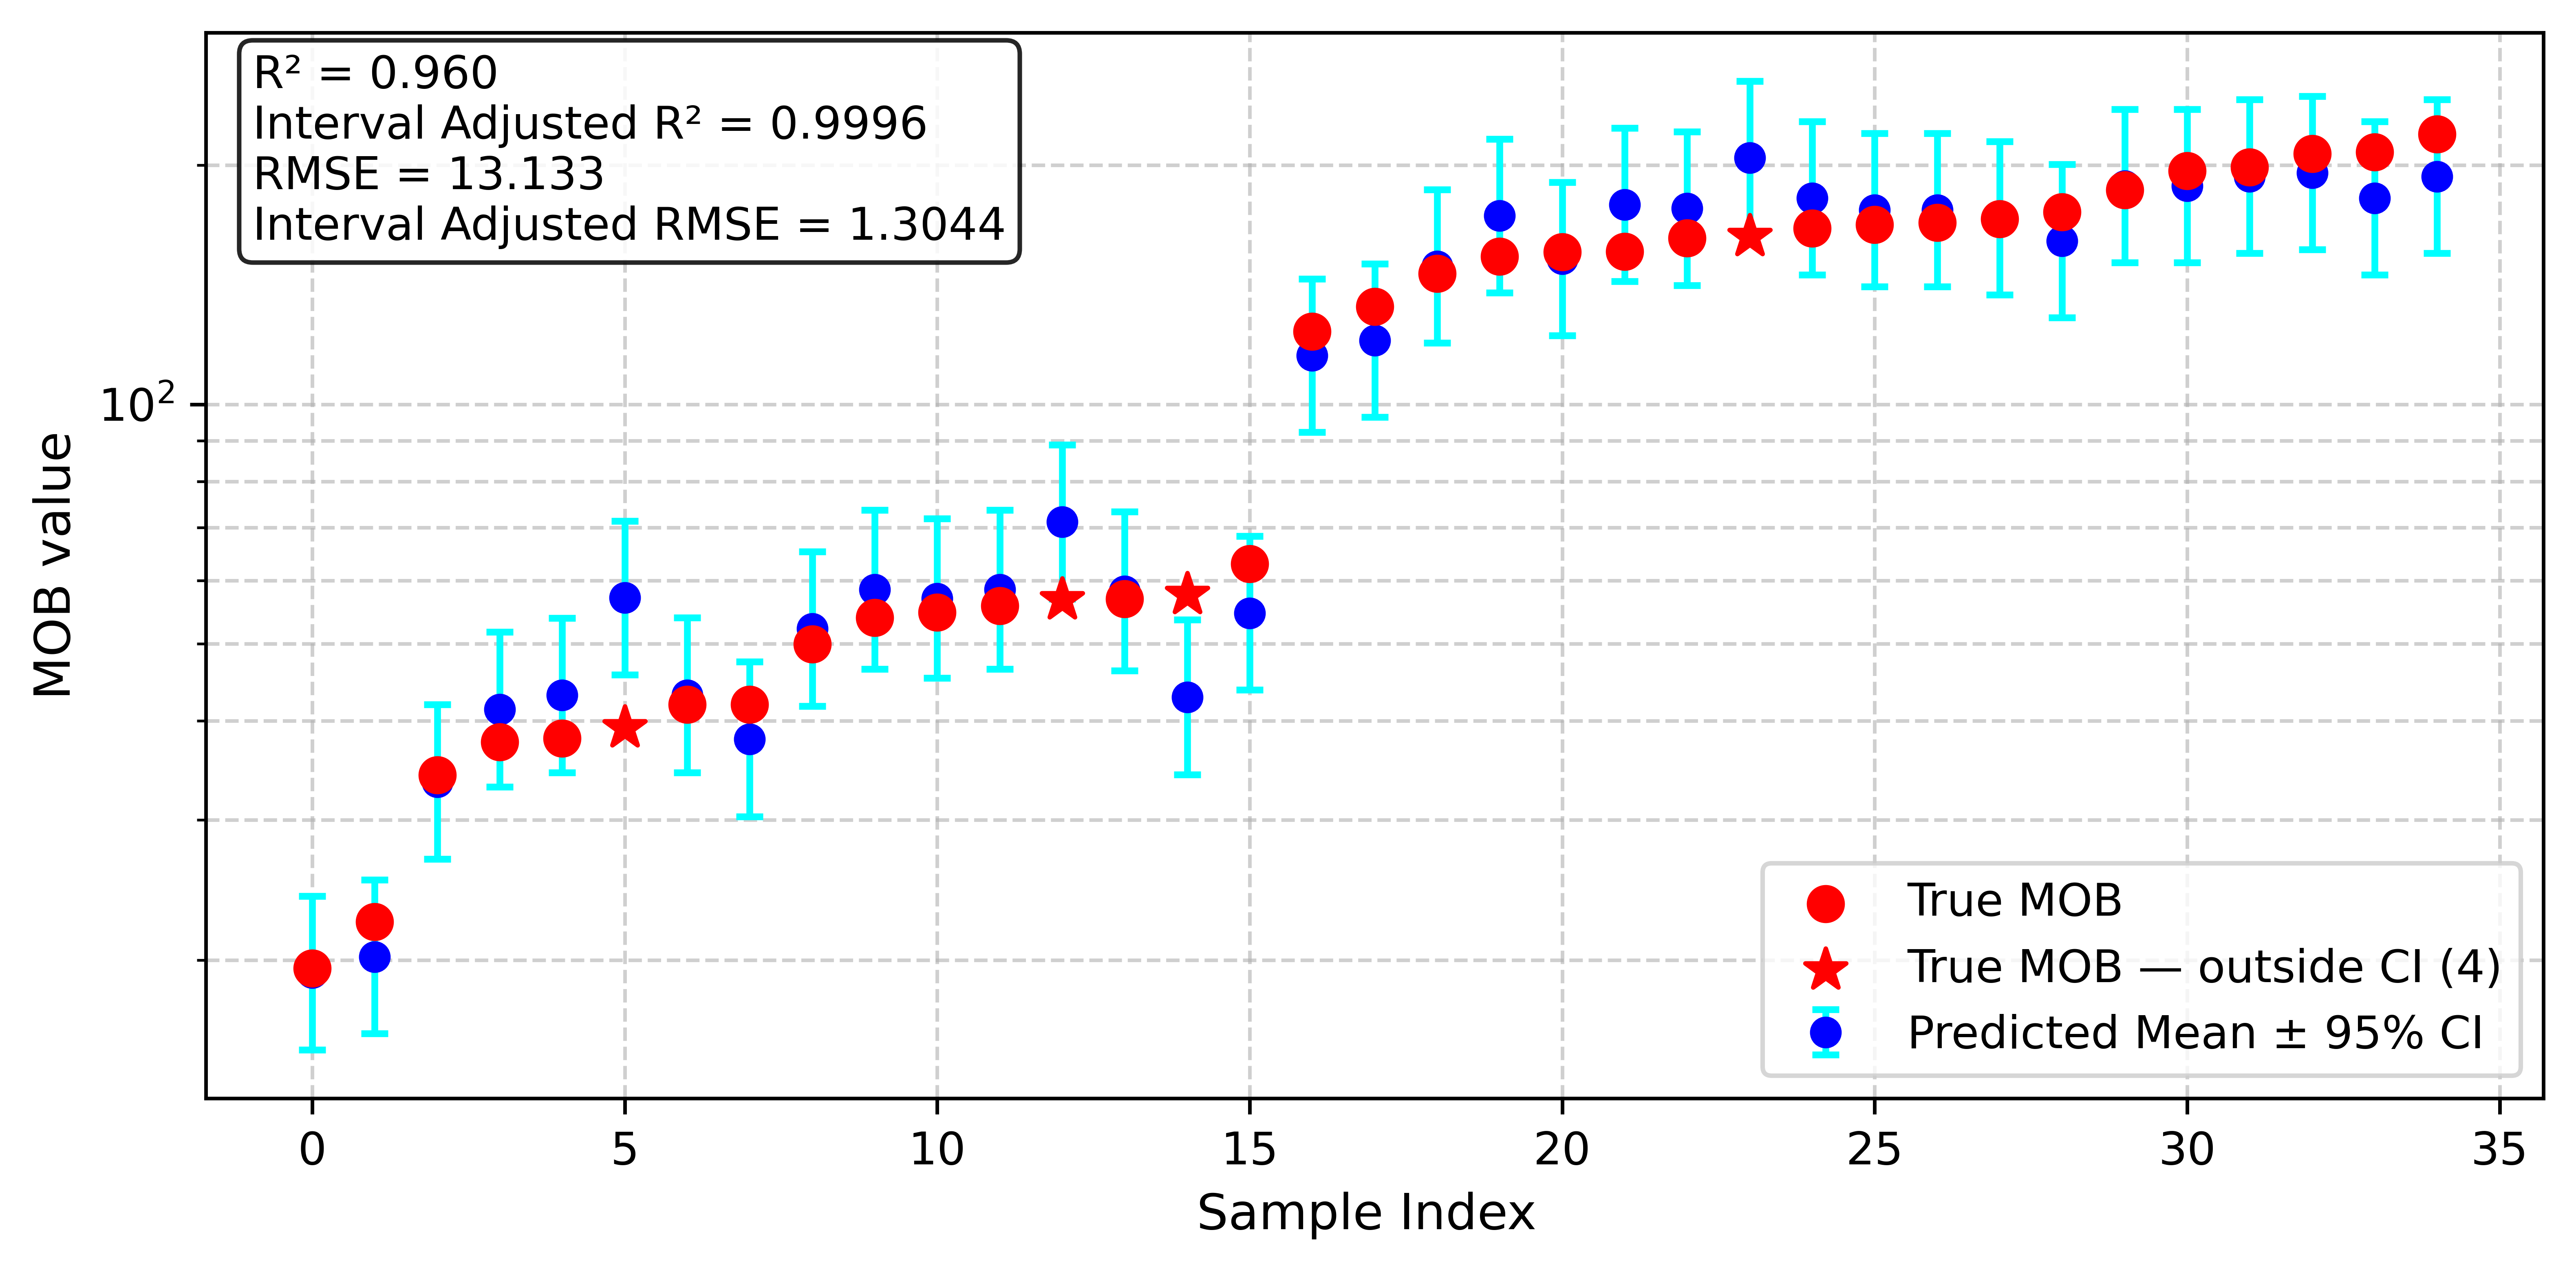

In [63]:
fig, ax = plt.subplots(figsize=(8, 4),dpi=800)

ax.errorbar(x_pos, y_pred_mean,
            yerr=[err_lower, err_upper],
            fmt='o',
            color='blue',
            ecolor='cyan',
            elinewidth=1.5,
            capsize=3,
            capthick=1.5,
            markersize=6,
            zorder=2,
            label='Predicted Mean ± 95% CI')

# True values — colored by inside/outside CI
ax.scatter(x_pos[inside_mask],  y_actual[inside_mask],
           color='red', s=55, zorder=3,
           label='True MOB')
ax.scatter(x_pos[outside_mask], y_actual[outside_mask],
           color='red', s=90, marker='*', zorder=4,
           label=f'True MOB — outside CI ({n_outside})')

ax.set_yscale("log")
ax.set_xlabel("Sample Index ", fontsize=11)
ax.set_ylabel("MOB value",        fontsize=11)
metrics_text = (
    f"R² = {r2_standard:.3f}\n"
    f"Interval Adjusted R² = {r2_adjusted:.4f}\n"
    f"RMSE = {rmse_standard:.3f}\n"
    f"Interval Adjusted RMSE = {rmse_adjusted:.4f}"
)

ax.text(
    0.02, 0.98,                 
    metrics_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.85,
        edgecolor='black'
    )
)
ax.legend(fontsize=10)
ax.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# ALL ML models performance

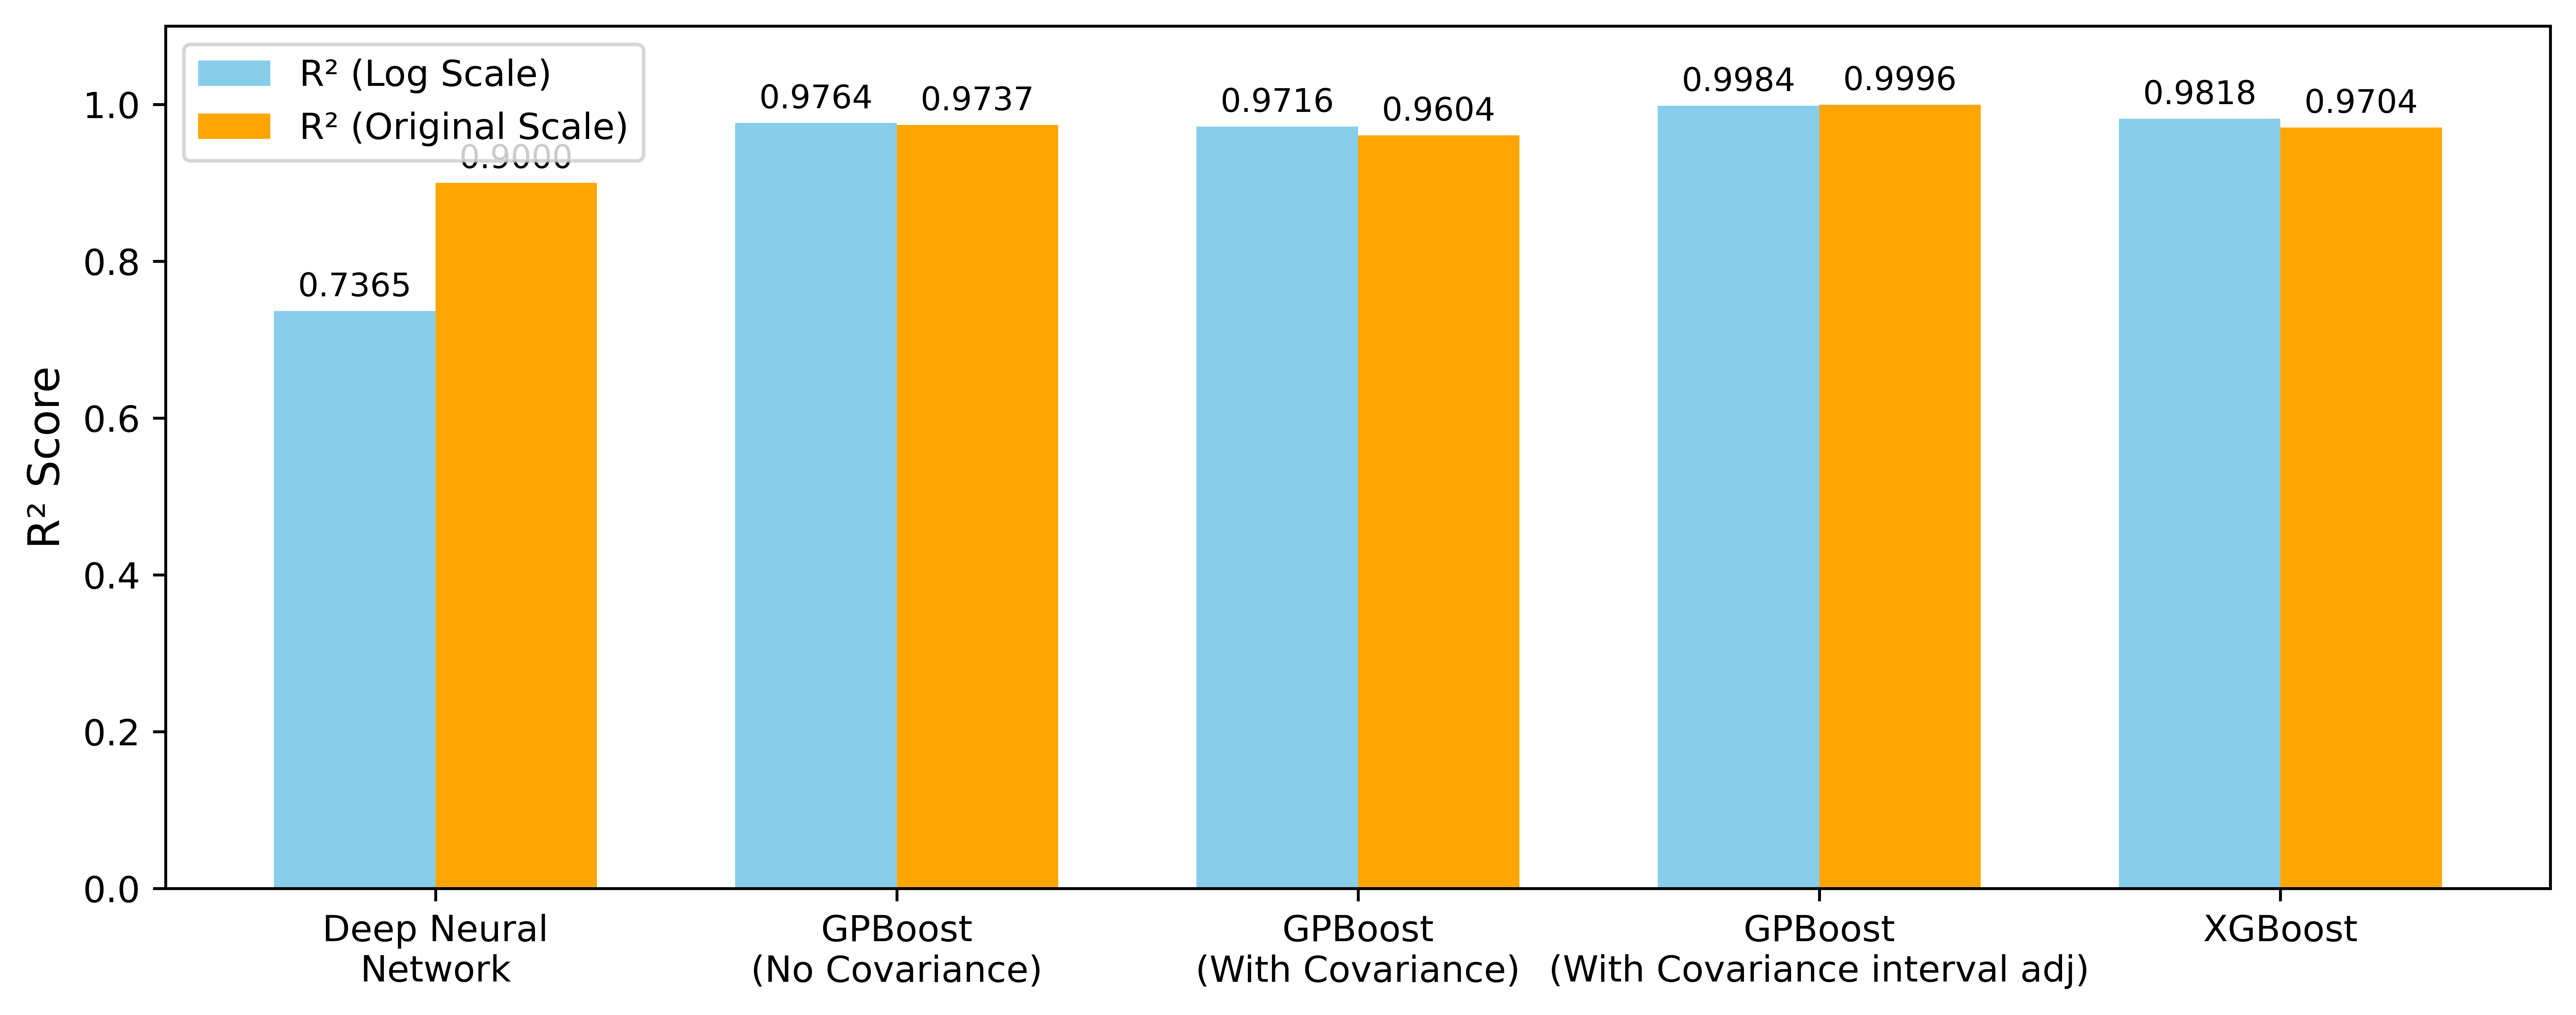

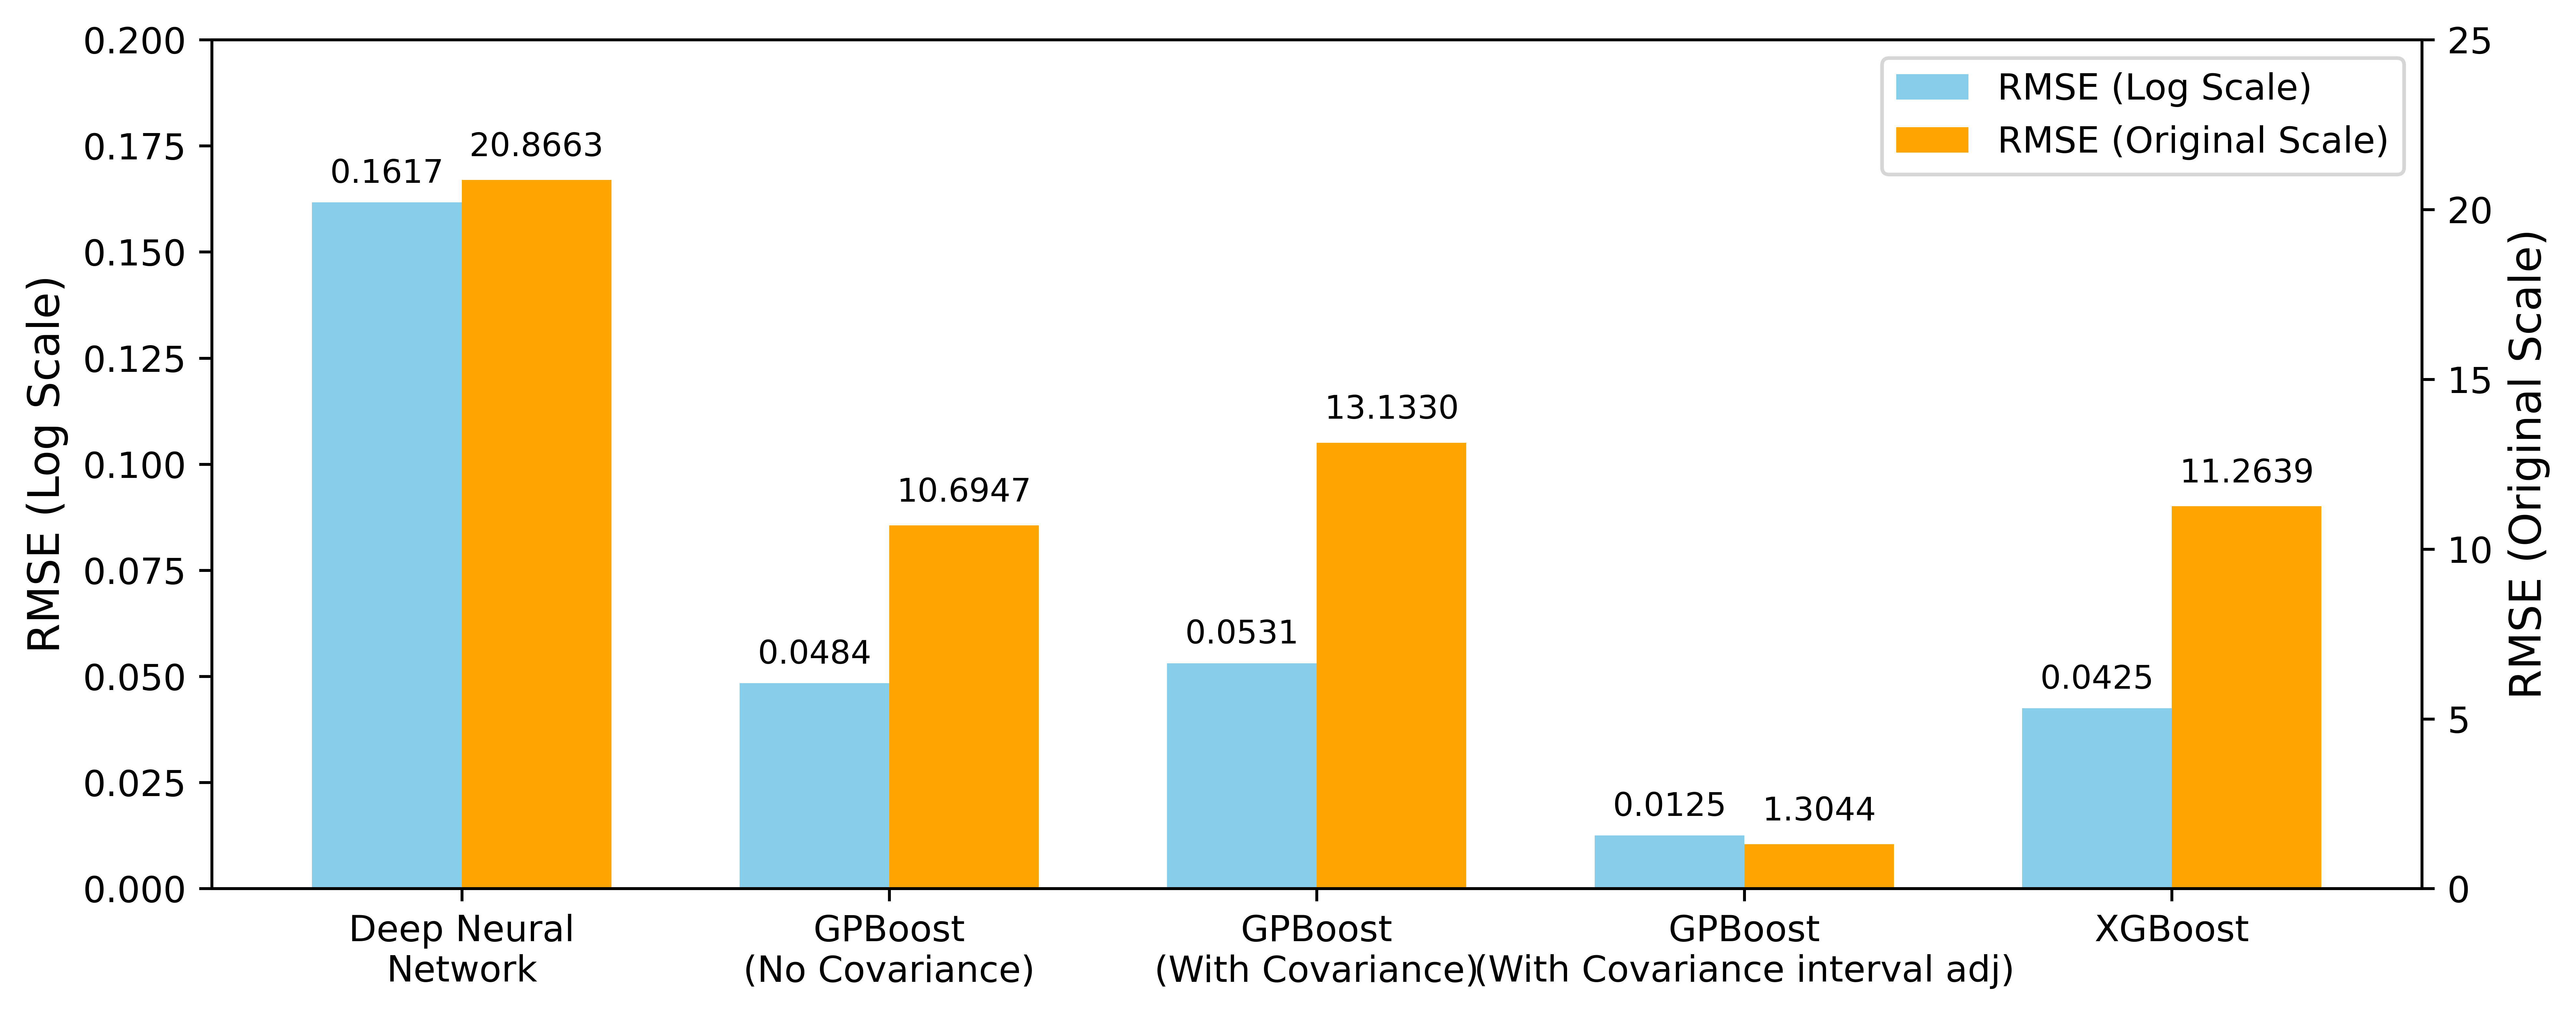

In [76]:
models = [
    "Deep Neural\nNetwork",
    "GPBoost\n(No Covariance)",
    "GPBoost\n(With Covariance)",
    "GPBoost\n(With Covariance interval adj)",
    "XGBoost"
]

# =========================
# Metrics
# =========================
r2_log = [0.7365, 0.9764, 0.9716, 0.9984, 0.9818]
r2_real = [0.9000, 0.9737, 0.9604, 0.9996, 0.9704]

rmse_log = [0.1617, 0.0484, 0.0531, 0.0125, 0.0425]
rmse_real = [20.8663, 10.6947, 13.133, 1.3044, 11.2639]

x = np.arange(len(models))
width = 0.35

# ==========================================================
# 1. R² Comparison Figure
# ==========================================================
plt.figure(figsize=(10,4),dpi=800)

bars1 = plt.bar(
    x - width/2,
    r2_log,
    width,
    label='R² (Log Scale)',
    color='skyblue'
)

bars2 = plt.bar(
    x + width/2,
    r2_real,
    width,
    label='R² (Original Scale)',
    color='orange'
)

plt.ylabel('R² Score', fontsize=12)
plt.xticks(x, models, fontsize=10)
plt.ylim(0, 1.1)
plt.legend(fontsize=10)

# Add values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()


# ==========================================================
# 2. RMSE Comparison Figure
# ==========================================================
fig, ax1 = plt.subplots(figsize=(10, 4),dpi=800)

# RMSE log scale bars
bars3 = ax1.bar(
    x - width/2,
    rmse_log,
    width,
    label='RMSE (Log Scale)',
    color='skyblue'
)

ax1.set_ylabel('RMSE (Log Scale)', fontsize=12)
ax1.set_ylim(0, 0.20)
5
# RMSE original scale bars
ax2 = ax1.twinx()

bars4 = ax2.bar(
    x + width/2,
    rmse_real,
    width,
    label='RMSE (Original Scale)',
    color='orange'
)

ax2.set_ylabel('RMSE (Original Scale)', fontsize=12)
ax2.set_ylim(0, 25)

# X-axis
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=10)

# Add values for RMSE log scale
for bar in bars3:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add values for RMSE real scale
for bar in bars4:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper right',
    fontsize=10
)

plt.tight_layout()
plt.show()